In [4]:
import pandas as pd
import numpy as np

In [5]:
import pandas as pd
import seaborn as sns

In [6]:
#https://www.kaggle.com/datasets/sonalshinde123/student-placement-dataset
from pandas import read_csv
df=read_csv('C:\\college\\sem_2-1\\ML\\Placement-Prediction-System\\data\\player_performance_dataset_10000.csv')

In [8]:
# Numerical vs Categorical features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical Features:", list(numerical_features))
print("Categorical Features:", list(categorical_features))

Numerical Features: ['Age', 'Experience_Years', 'Matches_Played', 'Runs', 'Balls_Faced', 'Fours', 'Sixes', 'Strike_Rate', 'Batting_Average', 'Wickets', 'Overs_Bowled', 'Runs_Conceded', 'Economy', 'Catches', 'Stumpings', 'Recent_Form', 'Previous_Performance', 'Fitness_Score', 'Consistency_Score', 'Pressure_Score', 'Performance_Score']
Categorical Features: ['Player_ID', 'Player_Name', 'Role', 'Team', 'Match_ID', 'Match_Date', 'Match_Format', 'Opponent', 'Venue', 'Home_Away']


C:\Users\chvis\AppData\Local\Temp\ipykernel_27668\1869842994.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object']).columns


In [9]:
# Select only numerical columns for correlation
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numerical_cols].corr()

In [10]:
# Print matrix to terminal
print("\n--- Correlation Matrix ---")
print(corr_matrix)


--- Correlation Matrix ---
                           Age  Experience_Years  Matches_Played      Runs  \
Age                   1.000000          0.931852       -0.010595  0.024823   
Experience_Years      0.931852          1.000000       -0.010649  0.019885   
Matches_Played       -0.010595         -0.010649        1.000000  0.003895   
Runs                  0.024823          0.019885        0.003895  1.000000   
Balls_Faced           0.020164          0.018182        0.003460  0.791178   
Fours                 0.025170          0.019219        0.007380  0.881015   
Sixes                 0.012613          0.012179        0.011278  0.676896   
Strike_Rate           0.004734          0.000265        0.000431 -0.102925   
Batting_Average      -0.000691         -0.000907       -0.000799  0.502388   
Wickets              -0.000034         -0.002694        0.005619 -0.006075   
Overs_Bowled          0.007211          0.008628        0.002755 -0.013503   
Runs_Conceded         0.006314      

# Correlation Heatmap

To identify the relationship among numerical features and understand which variables are positively or negatively correlated before model development.
A correlation heatmap visualizes the Pearson correlation coefficient between numerical features.

The correlation coefficient (r) ranges from **-1 to +1**.

- **+1** → Perfect positive correlation
- **0** → No correlation
- **-1** → Perfect negative correlation

Generally,

- **0.70 to 1.00** → Strong positive correlation
- **0.40 to 0.69** → Moderate positive correlation
- **0.00 to 0.39** → Weak positive correlation
- **-0.40 to -0.69** → Moderate negative correlation
- **-0.70 to -1.00** → Strong negative correlation

##Example:

# **1. Coding Skills vs Certifications = 0.86**
Observation
-A strong positive relationship exists.
-Students with better coding skills usually earn more certifications.
-Certifications appear to reflect technical competency.


# 2. Student_ID, Correlation ≈ 0
Observation

- It has no relationship with placement or academic performance.
- It should be removed before model training.

#3.CGPA vs Backlogs = -0.58
    -As CGPA increases, the number of backlogs generally decreases.

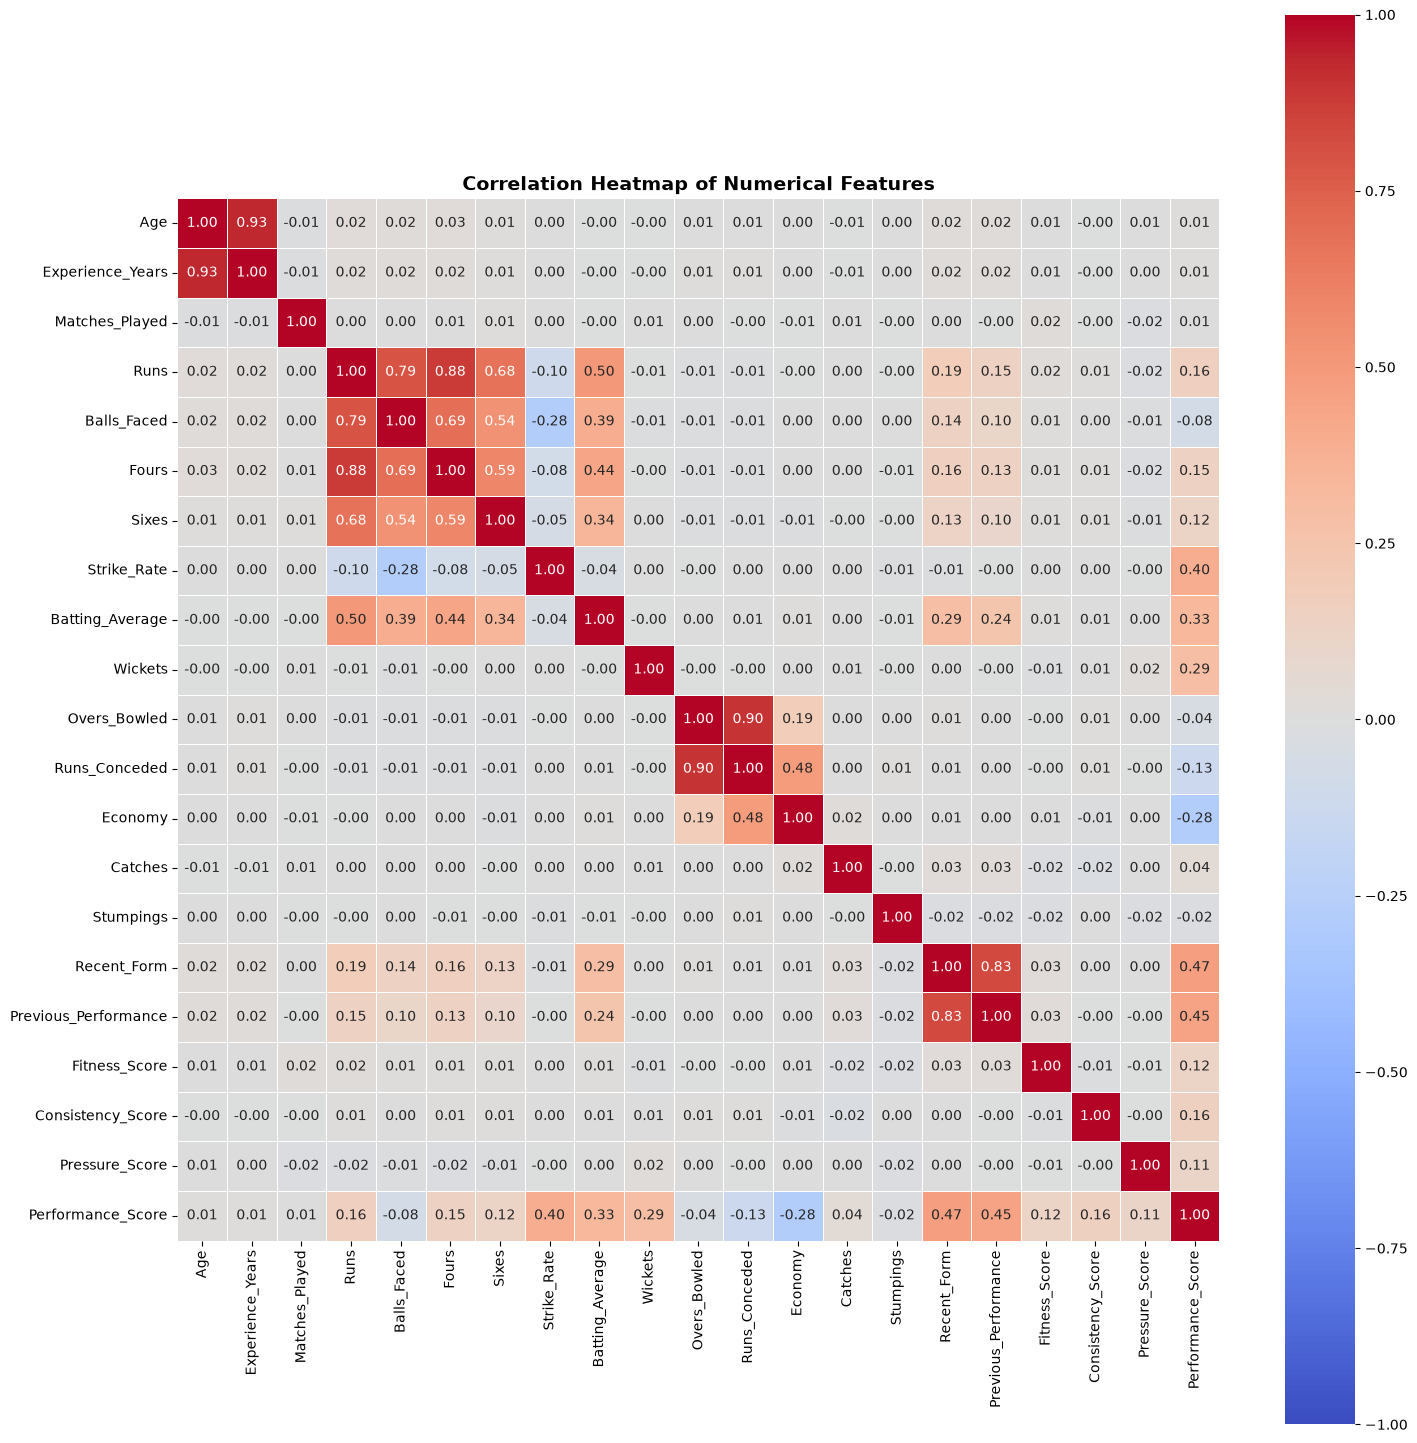

In [11]:
# Create Heatmap
import matplotlib.pyplot as plt
plt.figure(figsize=(15,15))
sns.heatmap(
corr_matrix,
annot=True,
cmap="coolwarm",
fmt=".2f",
vmin=-1,
vmax=1,
square=True,
linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\college\\sem_2-1\\ML\\Placement-Prediction-System\\data\\player_performance_dataset_10000.csv\\correlation_heatmap.png'

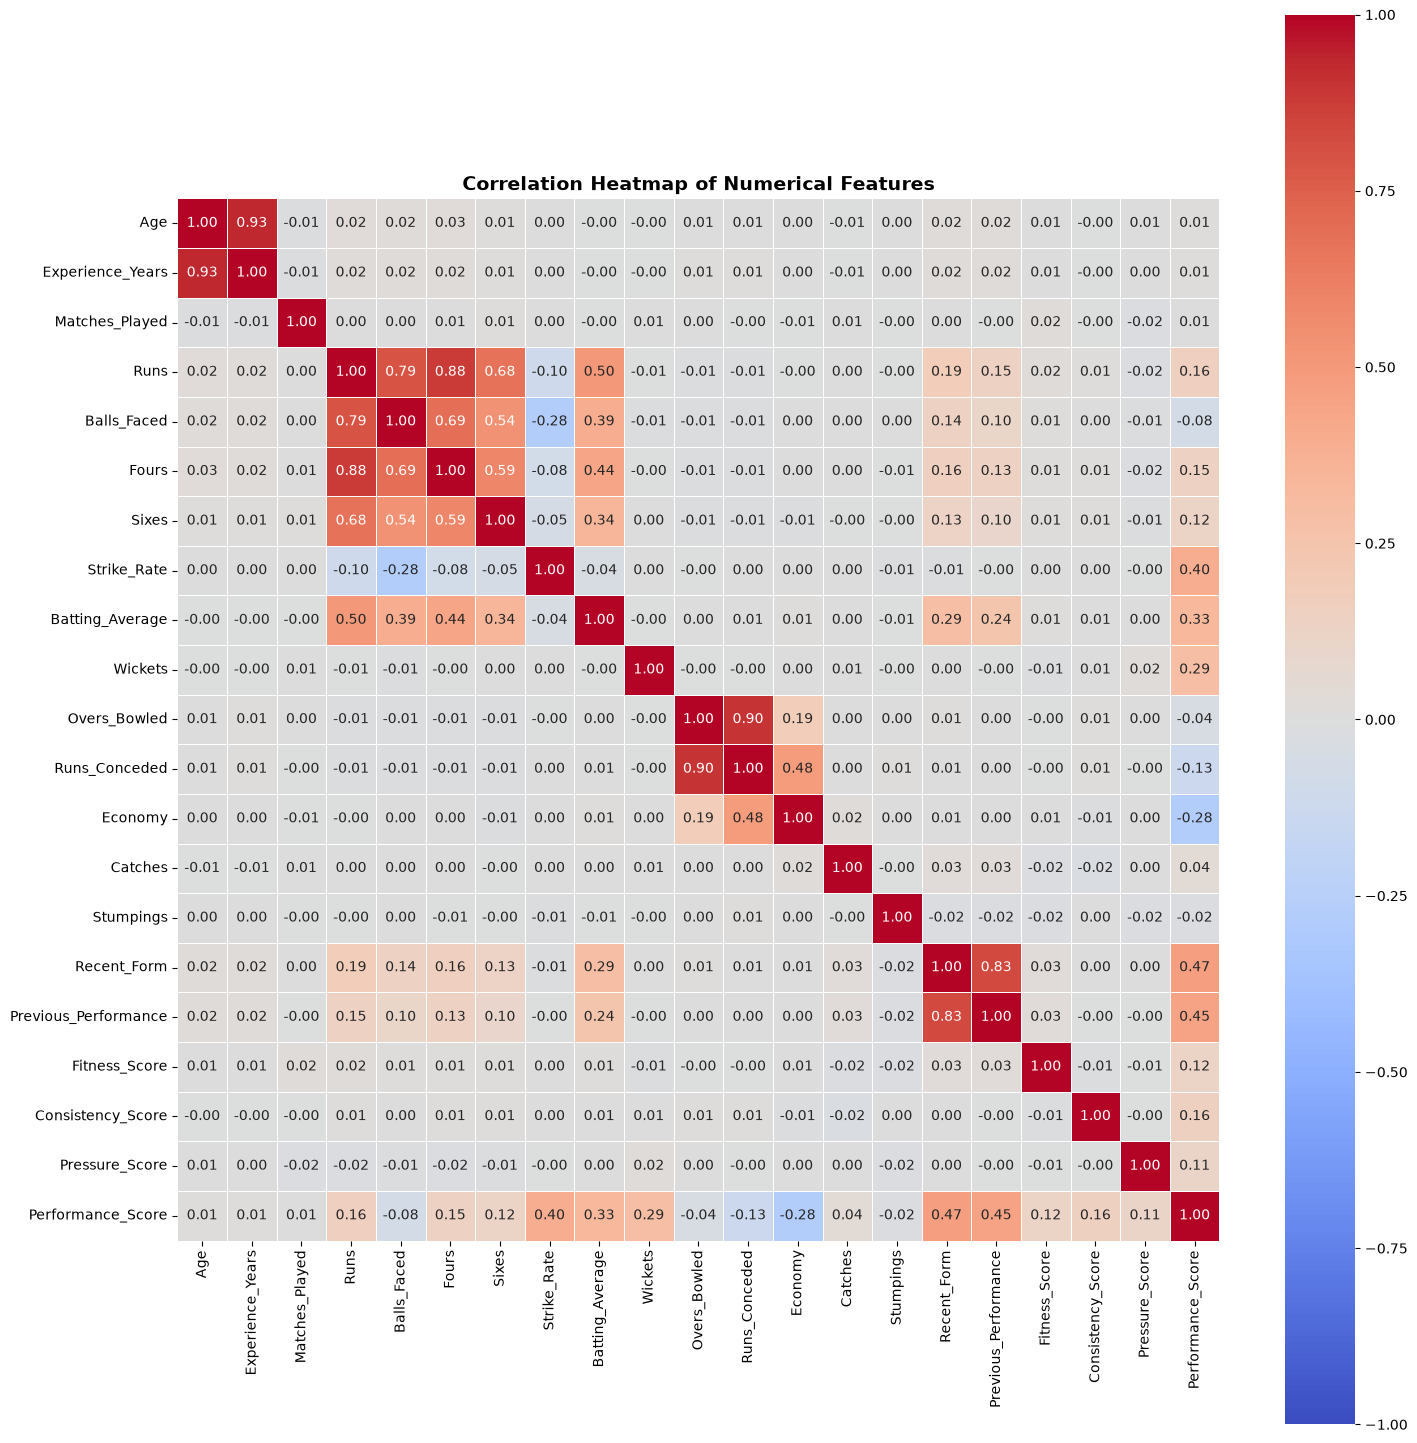

In [12]:
# Create Heatmap
import matplotlib.pyplot as plt
plt.figure(figsize=(15,15))
sns.heatmap(
corr_matrix,
annot=True,
cmap="coolwarm",
fmt=".2f",
vmin=-1,
vmax=1,
square=True,
linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()

# Export Heatmap
import os
output_dir = "C:\\college\\sem_2-1\\ML\\Placement-Prediction-System\\data\\player_performance_dataset_10000.csv"
heatmap_path = os.path.join(output_dir, "correlation_heatmap.png")
plt.savefig(heatmap_path, dpi=300)
plt.close()
print(f"Exported heatmap to: {heatmap_path}")

In [13]:

print(os.getcwd())

c:\college\sem_2-1\ML\Placement-Prediction-System\notebooks


In [15]:
# -------------------------------------------------------------
# 3. Produce Boxplots: Numerical Features vs PlacementStatus
# -------------------------------------------------------------
target_col = "PlacementStatus"
if target_col in df.columns:
    for col in numerical_cols:
        plt.figure(figsize=(6, 5))
        sns.boxplot(
            x=target_col,
            y=col,
            data=df,
            palette="Set2",
            hue=target_col,
            legend=False
        )
        plt.title(f"{col} vs {target_col}", fontsize=12, fontweight="bold")
        plt.xlabel(target_col)
        plt.ylabel(col)
        plt.tight_layout()
        

        # Save the boxplot
        boxplot_filename = f"boxplot_{col}_vs_{target_col}.png"

        # Create complete file path
        boxplot_path = os.path.join(output_dir, boxplot_filename)

        # Save the figure
        plt.savefig(boxplot_path,    dpi=300,    bbox_inches="tight")

        # Close the figure
        plt.close()

        # Display confirmation message
        print(f"Exported boxplot to: {boxplot_path}")

    else:
        print(f"\nTarget column '{target_col}' not found in dataset. Skipping boxplots.")

        print("\nAll EDA tasks completed successfully!")



In [16]:
#boxplots
numerical_columns = [
    "Age",
    "CGPA",
    "Internships",
    "Projects",
    "Coding_Skills",
    "Communication_Skills",
    "Aptitude_Test_Score",
    "Soft_Skills_Rating",
    "Certifications",
    "Backlogs"
]


fig6= plt.figure(figsize=(14,8))

df[numerical_columns].boxplot()

plt.xticks(rotation=45)

plt.show()

KeyError: "['CGPA', 'Internships', 'Projects', 'Coding_Skills', 'Communication_Skills', 'Aptitude_Test_Score', 'Soft_Skills_Rating', 'Certifications', 'Backlogs'] not in index"

<Figure size 1400x800 with 0 Axes>

In [17]:
fig7= sns.boxplot(x='Placement_Status', y='Certifications', data=df)

ValueError: Could not interpret value `Placement_Status` for `x`. An entry with this name does not appear in `data`.

In [ ]:
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages("EDA_Report.pdf") as pdf:

    pdf.savefig(fig1)
    pdf.savefig(fig2)
    pdf.savefig(fig3)
    pdf.savefig(fig5)
    pdf.savefig(fig6)
    

print("EDA Report saved successfully.")

In [ ]:
#==========================================================
# Export Complete EDA Report
#==========================================================

with PdfPages("EDA_Report.pdf") as pdf:

    #------------------------------------------------------
    # Page 1 : Missing Value Heatmap
    #------------------------------------------------------

    plt.figure(figsize=(12,6))

    sns.heatmap(df.isnull(),
                cbar=True,
                yticklabels=False,
                cmap="viridis")

    plt.title("Missing Value Heatmap")
    plt.xlabel("Features")
    plt.ylabel("Samples")

    pdf.savefig()
    plt.close()


    #------------------------------------------------------
    # Page 2 : Histograms (6 Features)
    #------------------------------------------------------

    numerical_features = [
        "CGPA",
        "Age",
        "Coding_Skills",
        "Communication_Skills",
        "Aptitude_Test_Score",
        "Backlogs"
    ]

    fig, axes = plt.subplots(3,2,figsize=(14,12))

    axes = axes.flatten()

    for i,col in enumerate(numerical_features):

        axes[i].hist(df[col],
                     bins=15,
                     edgecolor='black')

        axes[i].set_title(col)

    plt.tight_layout()

    pdf.savefig()
    plt.close()


    #------------------------------------------------------
    # Page 3 : Placement by Branch
    #------------------------------------------------------

    plt.figure(figsize=(10,6))

    sns.countplot(
        data=df,
        x="Branch",
        hue="Placement_Status"
    )

    plt.title("Placement Status by Branch")

    plt.xticks(rotation=45)

    pdf.savefig()
    plt.close()


    #------------------------------------------------------
    # Page 4 : Correlation Heatmap
    #------------------------------------------------------

    plt.figure(figsize=(10,8))

    corr = df.select_dtypes(include=np.number).corr()

    sns.heatmap(
        corr,
        annot=True,
        cmap="coolwarm",
        fmt=".2f"
    )

    plt.title("Correlation Heatmap")

    pdf.savefig()

    plt.close()


    #------------------------------------------------------
    # Page 5 : Boxplots
    #------------------------------------------------------

    fig, axes = plt.subplots(3,2,figsize=(14,12))

    axes = axes.flatten()

    for i,col in enumerate(numerical_features):

        sns.boxplot(
            y=df[col],
            ax=axes[i]
        )

        axes[i].set_title(col)

    plt.tight_layout()

    pdf.savefig()

    plt.close()

print("EDA_Report.pdf created successfully.")